# Decoration, guides and named camera views

Furniture that frames a scene and explains its colours, over the **real Grand Canyon DEM** and the **real
WorldPop population** choropleth:

- **Decoration** — `coastlines()`/`borders()` (Natural-Earth reference lines), `text()`, `axes()`/
  `orientation_axes()`, `set_title()`.
- **Guides** — `colorbar()` (continuous) and `legend()` (keyed classes).
- **Camera** — `view()` snaps to a named viewpoint.

*DEM: Copernicus WorldDEM-30 © DLR/Airbus (EU/ESA). Population: WorldPop — CC-BY-4.0.*

---
*Data.* All layers below are built from **real data downloaded with
[earthlens](https://github.com/serapeum-org/earthlens)** and committed as small fixtures under
`examples/data/`; vector and 3-D layers are derived from those real rasters through **pyramids** (the GIS
engine), so nothing here is synthetic. Attributions are given per dataset.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

pv.OFF_SCREEN = True  # headless: every scene renders to an image, no interactive window

import pyramids  # import first: bootstraps pyramids' vendored GDAL
from pyramids.dataset import Dataset
from digitalearth.three_d import Scene3D

ROOT = Path.cwd()
while not (ROOT / 'examples' / 'data' / 'real_dem_mont_blanc.tif').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / 'examples' / 'data'


def show(scene, title=''):
    """Screenshot a Scene3D off-screen and show it inline, asserting the scene area is not blank."""
    img = scene.screenshot()
    bg = img[0, 0].astype(int)
    area = img[: int(img.shape[0] * 0.8)]
    content = (np.abs(area.astype(int) - bg).sum(-1) > 30).mean()
    assert content > 0.01, f'render looks blank: only {content:.1%} differs from the background'
    plt.figure(figsize=(6, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()


def show_image(img, title=''):
    """Show an already-captured RGB frame (e.g. from a pyvista Plotter) inline."""
    plt.figure(figsize=(7, 4)); plt.imshow(img); plt.axis('off')
    if title:
        plt.title(title)
    plt.show()
import geopandas as gpd

## `coastlines()` and `borders()` — Natural-Earth reference lines

In a flat (non-globe) scene these draw real world reference geography as their own layers.

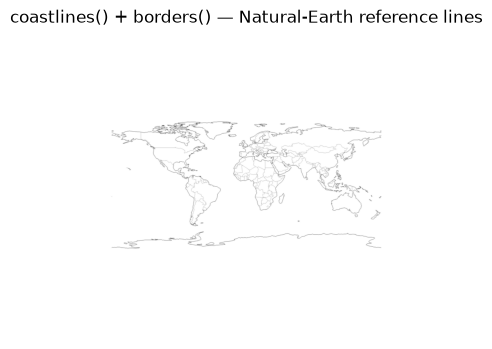

In [2]:
scene = Scene3D(off_screen=True)
scene.coastlines(color='black')
scene.borders(color='#888888')
scene.view('top')
show(scene, 'coastlines() + borders() — Natural-Earth reference lines')
scene.close()

## `text()` — a label at a coordinate

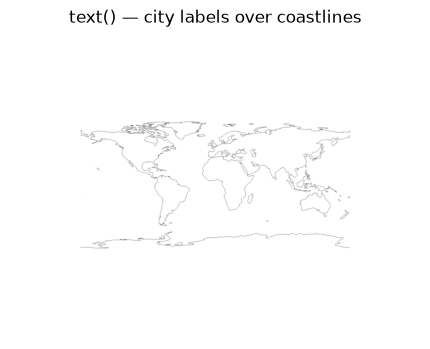

In [3]:
scene = Scene3D(off_screen=True)
scene.coastlines(color='black')
scene.text(-0.13, 51.5, 'London', text_size=16, color='crimson')
scene.text(2.35, 48.85, 'Paris', text_size=16, color='navy')
scene.view('top')
show(scene, 'text() — city labels over coastlines')
scene.close()

## `axes()`, `orientation_axes()`, `set_title()` — framing furniture

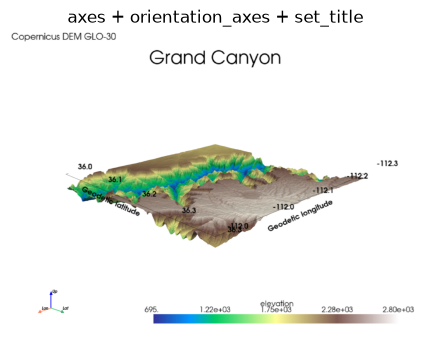

In [4]:
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=2.0, cmap='terrain')
scene.axes(show=True)
scene.orientation_axes(show=True)
scene.set_title('Grand Canyon', subtitle='Copernicus DEM GLO-30')
scene.view('isometric')
show(scene, 'axes + orientation_axes + set_title')
scene.close()

## `colorbar()` — a continuous scalar key

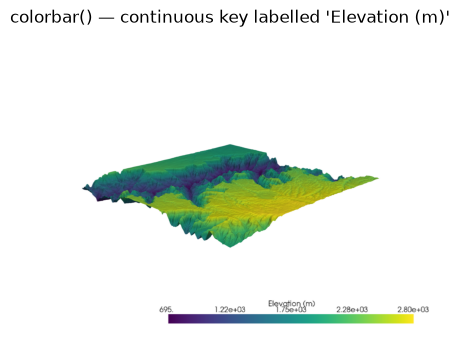

In [5]:
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
scene = Scene3D(off_screen=True)
scene.terrain(dem, z_exaggeration=2.0, cmap='viridis')
scene.colorbar(label='Elevation (m)')
scene.view('isometric')
show(scene, "colorbar() — continuous key labelled 'Elevation (m)'")
scene.close()

## `legend()` — keyed classes for a classified layer

The real population choropleth, with its quantile classes keyed.

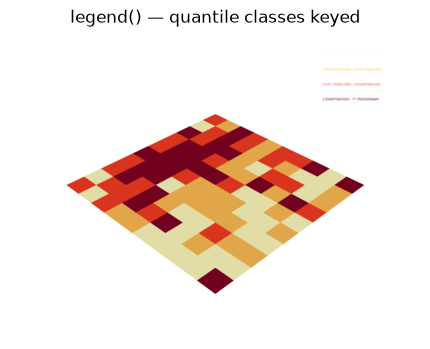

In [6]:
cells = (Dataset.read_file(str(DATA / 'real_population.tif'))
         .resample(0.03, method='nearest neighbor')
         .to_feature_collection(add_geometry='Polygon'))
cells = cells[cells['Band_1'] >= 0]
scene = Scene3D(off_screen=True)
scene.choropleth(cells, column='Band_1', scheme='quantiles', k=4, cmap='YlOrRd')
scene.legend(title='Population')
scene.view('isometric')
show(scene, 'legend() — quantile classes keyed')
scene.close()

## `view()` — named camera viewpoints

Shipped views: `back, bottom, front, isometric, left, right, top`.

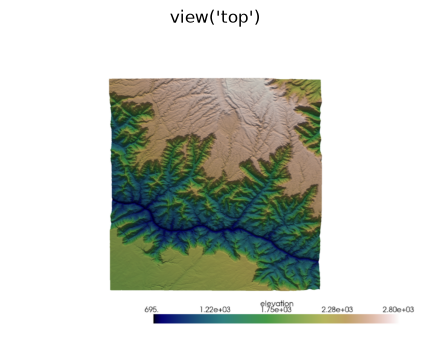

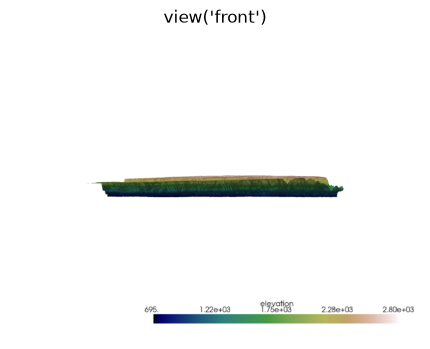

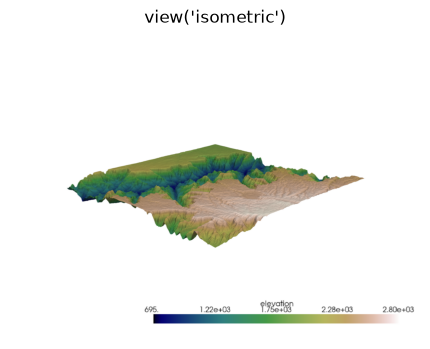

In [7]:
dem = Dataset.read_file(str(DATA / 'real_dem_grand_canyon.tif'))
for name in ('top', 'front', 'isometric'):
    scene = Scene3D(off_screen=True)
    scene.terrain(dem, z_exaggeration=2.0, cmap='gist_earth')
    scene.view(name)
    show(scene, f"view('{name}')")
    scene.close()